# 10 — Feature Engineering (GÜN 8)

Model için özellik türetme. Her feature, hangi alarm imzasını (WSM kategorisi)
yakalamak için var olduğu gerekçesiyle birlikte üretiliyor.

**Kapsam (6 feature grubu):**
1. Zaman (gece/gündüz, vardiya)
2. Satış–kayıp oranı (kk_oran ailesi)
3. Sıcaklık değişimi (dönemsel fark, günlük sapma, kayıpla korelasyon)
4. Hareketli ortalama (kayıp/kazanç, oran)
5. Kümülatif eğim (kumulatif_kayip_kazanc trend regresyonu)
6. Manifold eş-tank kazancı (bağlı tank çiftlerinde ters yönlü hareket)

Çıktı: `data/features.csv` — 30 dakikalık bazda, `ground_truth` etiketleriyle
birlikte (etiketler sadece değerlendirme için, **X feature seti içine
girmeyecek** — leakage yaratmamak için ayrı tutuluyor).

> Ground truth bu notebook'ta feature kalitesini görmek için birlikte
> yükleniyor (09'daki keşif kuralı burada geçerli değil, çünkü artık
> denetimli modele hazırlanıyoruz).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    FE_ROOT = ROOT.parent
elif ROOT.name == 'feature_engineering':
    FE_ROOT = ROOT
else:
    FE_ROOT = ROOT / 'feature_engineering'
EDA_ROOT = FE_ROOT.parent / 'eda'
DATA_ROOT = FE_ROOT.parent / 'data'
sys.path.insert(0, str(EDA_ROOT))
sys.path.insert(0, str(FE_ROOT))

from utils.data_loader import load_all
from fe_utils.fe_plots import (
    setup_fe_style, show_fig, plot_vardiya_counts, plot_hourly_kk,
    plot_gece_gunduz_box, plot_kk_oran_vs_satis, plot_sicaklik_features,
    plot_rolling_ma_example, plot_kum_egim_distribution, plot_manifold_ters_yon,
    plot_category_feature_means, plot_anomaly_rate_by_tank,
)

setup_fe_style()
%matplotlib inline
pd.set_option('display.max_columns', 60)

dfs = load_all()
ue1t = dfs['ue1t_30min'].copy()
tanks = dfs['tanks'].copy()
labels = pd.read_csv(
    DATA_ROOT / 'ground_truth' / 'labels_30min.csv',
    parse_dates=['saat_1', 'saat_2'],
)

ue1t = ue1t.sort_values(['istasyon_kodu', 'tank_no', 'saat_1']).reset_index(drop=True)
print('Veri:', DATA_ROOT)
print('Shape:', ue1t.shape, tanks.shape, labels.shape)
ue1t.head(3)

Veri: /Users/mangtay/Desktop/Staj/data
Shape: (138194, 16) (32, 11) (138194, 6)


,saat_1,saat_2,istasyon_kodu,tank_no,akaryakit_turu,sicaklik,donem_basi_stok,baslangic_seviyesi_cm,tanka_dolum,donem_sonu_stok,bitis_seviyesi_cm,tank_seviyesi_azalma_miktari,pompa_satis,kayip_kazanc,kumulatif_kayip_kazanc,oran
0,2026-01-01 00:00:00,2026-01-01 00:30:00,IST_001,1,Motorin(Excellium),19.86,16846.98,142.8331,0.0,16721.87,141.7724,125.11,122.89,-2.22,-2.22,-1.81
1,2026-01-01 00:30:00,2026-01-01 01:00:00,IST_001,1,Motorin(Excellium),19.66,16721.87,141.7724,0.0,16565.41,140.4459,156.46,153.59,-2.87,-5.09,-1.87
2,2026-01-01 01:00:00,2026-01-01 01:30:00,IST_001,1,Motorin(Excellium),19.53,16565.41,140.4459,0.0,16548.00,140.2983,17.41,14.83,-2.58,-7.67,-17.40


## 1) Zaman (gece/gündüz)

**Gerekçe:** `pompaci_manipulasyonu` ve `hayali_dolum`/`algilanmayan_dolum` gibi
insan kaynaklı kategoriler belirli vardiyalarda (özellikle gece, düşük gözetim
saatlerinde) yoğunlaşır. `gun_sonu_dolum` belirli bir saat penceresinde olur.
Zaman bilgisi olmadan bu kategoriler diğer sensör kaynaklı anomalilerden
(sızıntı, sıcaklık) ayrıştırılamaz.

In [2]:
ue1t['saat'] = ue1t['saat_1'].dt.hour
ue1t['gun'] = ue1t['saat_1'].dt.date
ue1t['haftanin_gunu'] = ue1t['saat_1'].dt.dayofweek  # 0=Pzt
ue1t['hafta_sonu'] = ue1t['haftanin_gunu'].isin([5, 6]).astype(int)

# Gece penceresi: 00:00-06:00 -> düşük gözetim / düşük satış saatleri
ue1t['gece'] = ue1t['saat'].between(0, 5).astype(int)

def vardiya(saat):
    if 0 <= saat < 6:
        return 'gece'
    if 6 <= saat < 14:
        return 'sabah'
    if 14 <= saat < 22:
        return 'aksam'
    return 'gece'  # 22-24

ue1t['vardiya'] = ue1t['saat'].apply(vardiya)

print(ue1t['vardiya'].value_counts())
print('\ngece oranı:', ue1t['gece'].mean().round(3))

vardiya
aksam    46080
gece     46074
sabah    46040
Name: count, dtype: int64

gece oranı: 0.25


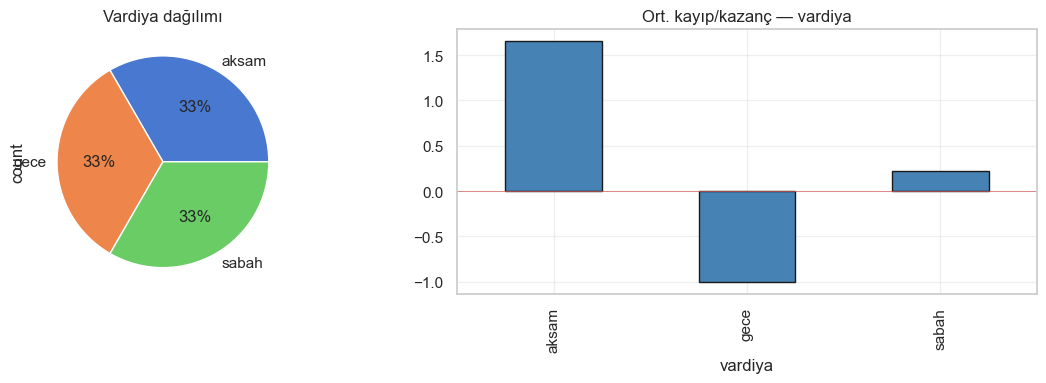

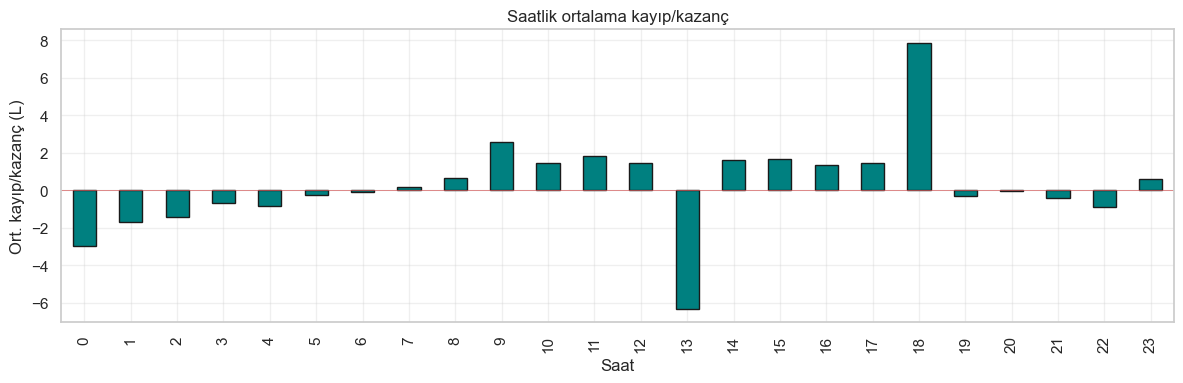

/Users/mangtay/Desktop/Staj/feature_engineering/fe_utils/fe_plots.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="gece", y="kayip_kazanc", ax=ax,
/Users/mangtay/Desktop/Staj/feature_engineering/fe_utils/fe_plots.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Gündüz", "Gece"])


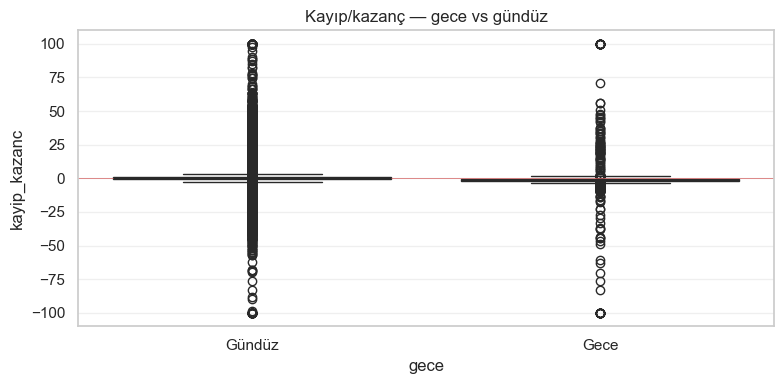

In [3]:
# Görselleştirme — zaman
plot_vardiya_counts(ue1t)
plot_hourly_kk(ue1t)
plot_gece_gunduz_box(ue1t)

## 2) Satış–kayıp oranı

**Gerekçe:** Mutlak `kayip_kazanc` litre cinsinden yanıltıcı — büyük tankta 10L
kayıp önemsiz, küçük tankta ciddi olabilir. Satışa oranlanmış kayıp:
- `pompa_kalibrasyon` ve `pompa_decimal`: satışla **orantılı, sabit yüzdelik**
  sapma bırakır (örn. her satışta -%0.3).
- `dinamik_sizinti`: satış olduğu sürece süren, satışla ilişkili ama sabit
  olmayan kayıp.
- `statik_sizinti` / `samandira_takilmasi`: satış **sıfırken** de kayıp devam
  eder → `kk_oran` tanımsız olur, ayrı bir `satisiz_kayip` bayrağı gerekir.

In [4]:
ue1t['kk_oran'] = np.where(
    ue1t['pompa_satis'].abs() > 1,
    ue1t['kayip_kazanc'] / ue1t['pompa_satis'],
    np.nan,
)
ue1t['kk_oran_abs'] = ue1t['kk_oran'].abs()

# Satışsızken kayıp/kazanç -> statik sızıntı / samandıra adayı
ue1t['satisiz_kayip'] = (
    (ue1t['pompa_satis'].abs() <= 1) & (ue1t['kayip_kazanc'].abs() > 3)
).astype(int)

print(ue1t[['kayip_kazanc', 'pompa_satis', 'kk_oran', 'satisiz_kayip']].describe())

        kayip_kazanc    pompa_satis       kk_oran  satisiz_kayip
count  138194.000000  138194.000000  92759.000000  138194.000000
mean        0.289401      61.818797     -0.011747       0.015782
std        93.555517      80.807458      2.613461       0.124632
min    -14138.410000       0.000000   -589.591743       0.000000
25%        -0.930000       0.000000     -0.009823       0.000000
50%        -0.090000      35.140000      0.001412       0.000000
75%         0.700000      93.247500      0.011684       0.000000
max     13540.130000    3695.400000    116.745387       1.000000


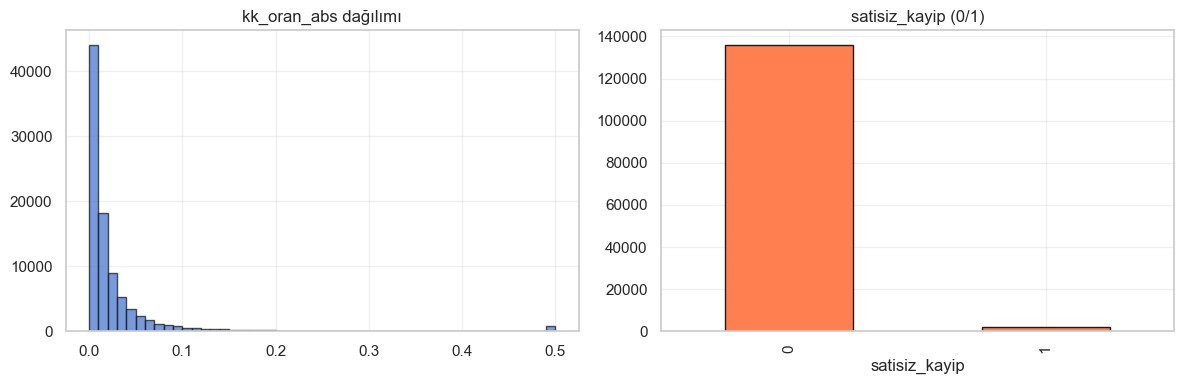

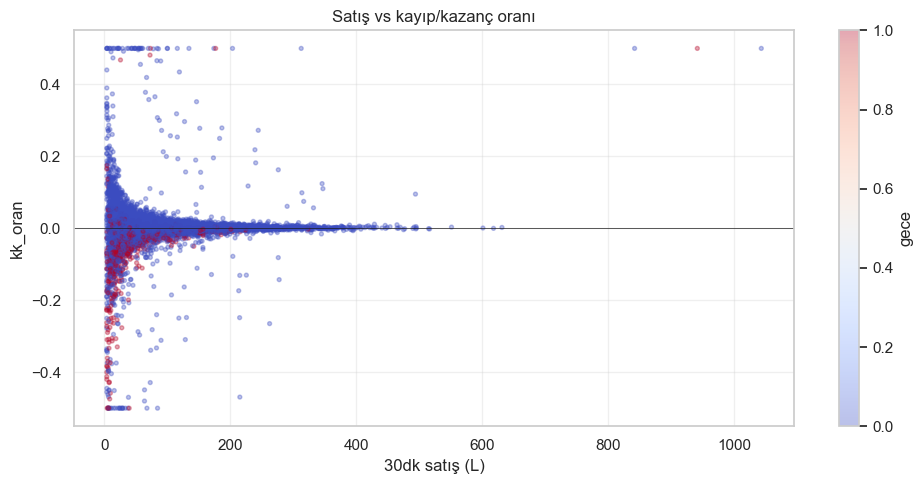

In [5]:
# Görselleştirme — kk_oran
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ue1t['kk_oran_abs'].dropna().clip(0, 0.5).hist(bins=50, ax=axes[0], edgecolor='k', alpha=0.75)
axes[0].set_title('kk_oran_abs dağılımı')
ue1t['satisiz_kayip'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='k')
axes[1].set_title('satisiz_kayip (0/1)')
plt.tight_layout(); show_fig()
plot_kk_oran_vs_satis(ue1t)

## 3) Sıcaklık değişimi

**Gerekçe:** `sicaklik_degisimi` kategorisi doğrudan sıcaklık hareketiyle
tanımlanır (termal genleşme/büzülme hacmi etkiler, gerçek kayıp değildir).
`su_faktoru` da sıcaklığa bağlı yoğunluk değişimiyle karışabilir. Üç açıdan
bakıyoruz:
- **Dönemsel fark** (`sicaklik_fark`): ani sıçrama var mı?
- **Günlük ortalamadan sapma**: o gün için anormal mi, yoksa mevsimsel mi?
- **Sıcaklık–kayıp korelasyonu** (rolling): kayıp sıcaklıkla birlikte mi
  hareket ediyor (→ termal, gerçek sızıntı değil) yoksa bağımsız mı
  (→ gerçek sızıntı şüphesi)?

In [6]:
g = ue1t.groupby(['istasyon_kodu', 'tank_no'])

ue1t['sicaklik_fark'] = g['sicaklik'].diff()

gunluk_ort_sicaklik = (
    ue1t.groupby(['istasyon_kodu', 'tank_no', 'gun'])['sicaklik']
    .transform('mean')
)
ue1t['sicaklik_gunluk_sapma'] = ue1t['sicaklik'] - gunluk_ort_sicaklik

def rolling_corr(frame, w=12):
    return frame['sicaklik_fark'].rolling(w, min_periods=6).corr(frame['kayip_kazanc'])

ue1t['sicaklik_kayip_korelasyon'] = (
    ue1t.groupby(['istasyon_kodu', 'tank_no'], group_keys=False)
    .apply(rolling_corr)
)

ue1t[['sicaklik', 'sicaklik_fark', 'sicaklik_gunluk_sapma', 'sicaklik_kayip_korelasyon']].describe()

/var/folders/s1/b7rcr9bj2qd0991bpssq9vyh0000gn/T/ipykernel_32021/4256161664.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rolling_corr)


,sicaklik,sicaklik_fark,sicaklik_gunluk_sapma,sicaklik_kayip_korelasyon
count,137954.000000,137917.000000,1.379540e+05,137733.000000
mean,20.164989,0.000167,-5.034689e-17,0.628768
std,2.177647,0.340243,1.160266e+00,0.288752
min,0.000000,-21.620000,-1.507250e+01,-0.998177
25%,18.500000,-0.120000,-9.605729e-01,0.476067
50%,20.210000,-0.010000,-4.979167e-02,0.688457
75%,21.750000,0.100000,8.860417e-01,0.840600
max,27.450000,21.140000,6.771042e+00,0.999967


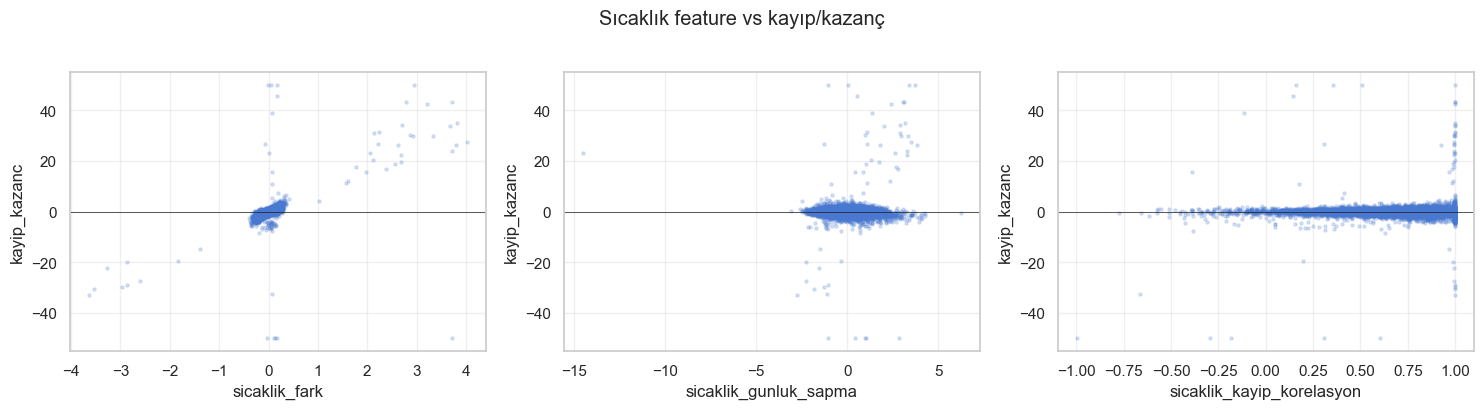

In [7]:
# Görselleştirme — sıcaklık feature
plot_sicaklik_features(ue1t)

## 4) Hareketli ortalama

**Gerekçe:** Tek dönemlik `kayip_kazanc` gürültülü (ölçüm hatası, ani satış
dalgalanması). Hareketli ortalama gürültüyü bastırır:
- Kısa pencere (3 dönem = 1.5 saat): kısa süreli olayları (manipülasyon,
  ölçüm sıçraması) ayırt eder.
- Uzun pencere (48 dönem = 1 gün): **sürekli** sızıntıyı (statik/dinamik)
  günlük gürültüden ayırır — sürekli negatif MA, gerçek sızıntının imzasıdır.

In [8]:
def add_rolling(frame, col, windows=(3, 6, 48)):
    frame = frame.copy()
    for w in windows:
        frame[f'{col}_ma_{w}'] = frame[col].rolling(w, min_periods=max(2, w // 3)).mean()
    return frame

ue1t = (
    ue1t.groupby(['istasyon_kodu', 'tank_no'], group_keys=False)
    .apply(lambda f: add_rolling(f, 'kayip_kazanc'))
)
ue1t = (
    ue1t.groupby(['istasyon_kodu', 'tank_no'], group_keys=False)
    .apply(lambda f: add_rolling(f, 'kk_oran', windows=(6,)))
)

ue1t[['kayip_kazanc', 'kayip_kazanc_ma_3', 'kayip_kazanc_ma_6',
      'kayip_kazanc_ma_48', 'kk_oran_ma_6']].describe()

/var/folders/s1/b7rcr9bj2qd0991bpssq9vyh0000gn/T/ipykernel_32021/1190204783.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda f: add_rolling(f, 'kayip_kazanc'))


/var/folders/s1/b7rcr9bj2qd0991bpssq9vyh0000gn/T/ipykernel_32021/1190204783.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda f: add_rolling(f, 'kk_oran', windows=(6,)))


,kayip_kazanc,kayip_kazanc_ma_3,kayip_kazanc_ma_6,kayip_kazanc_ma_48,kk_oran_ma_6
count,138194.000000,138162.000000,138162.000000,137714.000000,120808.000000
mean,0.289401,0.289824,0.289506,0.289137,-0.015941
std,93.555517,54.967933,40.719983,15.941525,1.269050
min,-14138.410000,-4696.283333,-2347.903333,-293.655000,-146.723139
25%,-0.930000,-0.840000,-0.808333,-0.153125,-0.015045
50%,-0.090000,-0.080000,-0.075000,-0.013125,0.001429
75%,0.700000,0.636667,0.640000,0.116042,0.014303
max,13540.130000,4580.113333,2312.308333,898.400208,24.149077


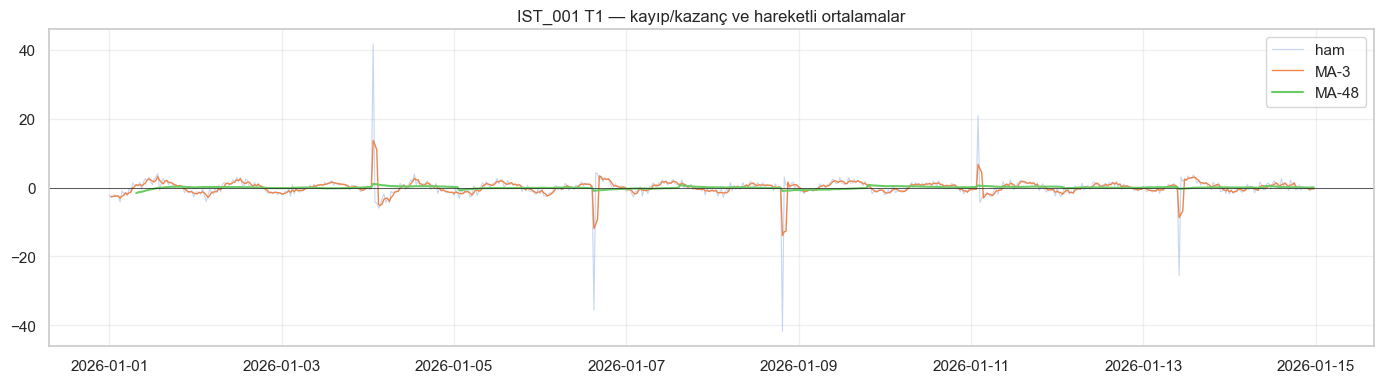

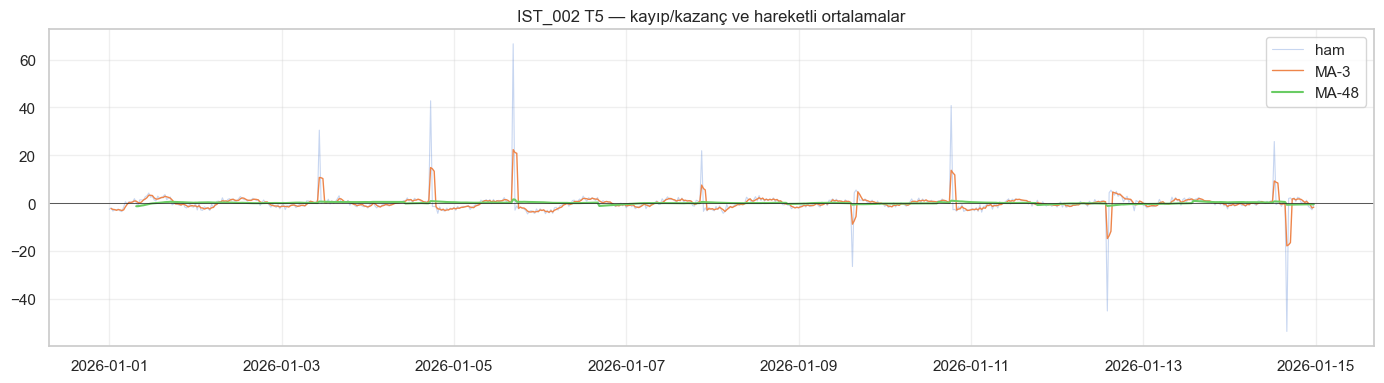

In [9]:
# Görselleştirme — rolling MA
plot_rolling_ma_example(ue1t, 'IST_001', 1)
plot_rolling_ma_example(ue1t, 'IST_002', 5)

## 5) Kümülatif eğim

**Gerekçe:** `kumulatif_kayip_kazanc` zaten veride var; ama önemli olan onun
**eğimi**. Sabit, negatif ve **düşük gürültülü** bir eğim → klasik
`statik_sizinti` imzası (sabit debili sızıntı). Satışla orantılı, satışla
birlikte açılıp kapanan eğim → `dinamik_sizinti`. Ani/tek seferlik basamak →
`mapping_hatasi` veya manipülasyon adayı (regresyon uyumu düşük — R² düşük).

Rolling pencerede lineer regresyon eğimi (`egim`) ve uyum kalitesi (`egim_r2`)
hesaplıyoruz.

In [10]:
def rolling_slope_r2(series, w=12):
    n = len(series)
    slopes = np.full(n, np.nan)
    r2s = np.full(n, np.nan)
    x = np.arange(w)
    x_mean = x.mean()
    ss_xx = ((x - x_mean) ** 2).sum()
    vals = series.values
    for i in range(w - 1, n):
        y = vals[i - w + 1: i + 1]
        if np.isnan(y).any():
            continue
        y_mean = y.mean()
        slope = ((x - x_mean) * (y - y_mean)).sum() / ss_xx
        yhat = y_mean + slope * (x - x_mean)
        ss_res = ((y - yhat) ** 2).sum()
        ss_tot = ((y - y_mean) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 1e-9 else 0.0
        slopes[i] = slope
        r2s[i] = r2
    return pd.Series(slopes, index=series.index), pd.Series(r2s, index=series.index)

def add_slope(frame, w=12):
    frame = frame.copy()
    slope, r2 = rolling_slope_r2(frame['kumulatif_kayip_kazanc'], w=w)
    frame['kum_egim'] = slope
    frame['kum_egim_r2'] = r2
    return frame

ue1t = (
    ue1t.groupby(['istasyon_kodu', 'tank_no'], group_keys=False)
    .apply(lambda f: add_slope(f, w=12))  # 12 dönem = 6 saat
)

ue1t[['kumulatif_kayip_kazanc', 'kum_egim', 'kum_egim_r2']].describe()

/var/folders/s1/b7rcr9bj2qd0991bpssq9vyh0000gn/T/ipykernel_32021/3287275163.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda f: add_slope(f, w=12))  # 12 dönem = 6 saat


,kumulatif_kayip_kazanc,kum_egim,kum_egim_r2
count,138194.000000,137842.000000,137842.000000
mean,354.025168,0.292779,0.734063
std,4186.891481,32.930813,0.296973
min,-14996.210000,-1744.195839,0.000000
25%,-79.317500,-0.767963,0.581653
50%,-12.995000,-0.069353,0.874909
75%,24.750000,0.653322,0.962005
max,43153.060000,1740.341888,0.999837


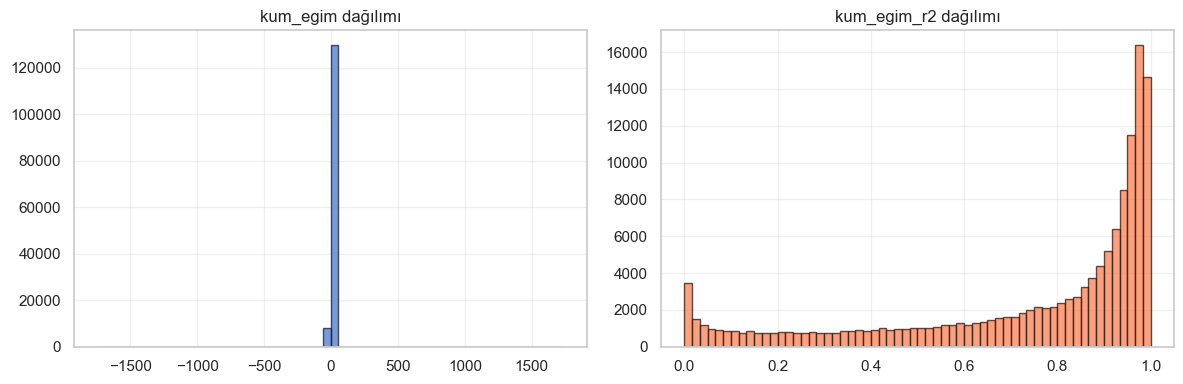

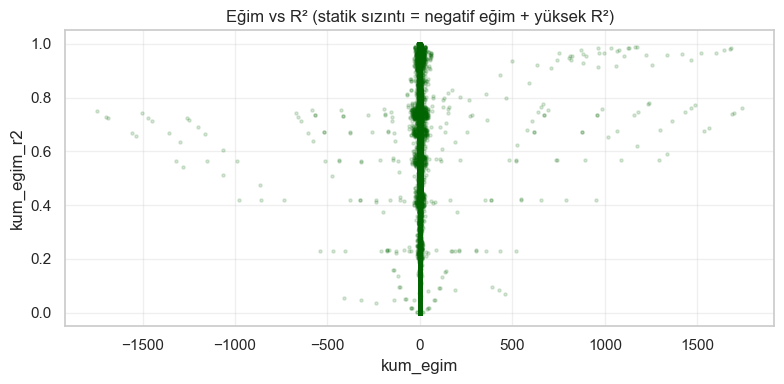

In [11]:
# Görselleştirme — kümülatif eğim
plot_kum_egim_distribution(ue1t)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ue1t['kum_egim'].dropna(), ue1t.loc[ue1t['kum_egim'].notna(), 'kum_egim_r2'],
           alpha=0.15, s=5, c='darkgreen')
ax.set_xlabel('kum_egim'); ax.set_ylabel('kum_egim_r2')
ax.set_title('Eğim vs R² (statik sızıntı = negatif eğim + yüksek R²)')
plt.tight_layout(); show_fig()

## 6) Manifold eş-tank kazancı

**Gerekçe:** `manifold_yakit_gecisi` ve `yakit_gecisi`, birbirine bağlı
(manifold) tanklar arasında yakıtın bir tanktan diğerine sızmasıyla oluşur:
biri kaybederken bağlı komşusu kazanır. Bu **tek tank bazında görünmez** —
aynı `manifold_grup_no` içindeki tankların aynı zaman diliminde birlikte
incelenmesi gerekir.

In [12]:
manifold_tanks = tanks[tanks['is_manifold'] == 1][
    ['istasyon_kodu', 'tank_no', 'manifold_grup_no']
]
print('Manifold tank sayısı:', len(manifold_tanks))
manifold_tanks.head()

Manifold tank sayısı: 8


,istasyon_kodu,tank_no,manifold_grup_no
0,IST_001,1,1
2,IST_001,3,1
14,IST_004,2,1
16,IST_004,4,1
18,IST_005,1,1


In [13]:
ue1t = ue1t.merge(
    tanks[['istasyon_kodu', 'tank_no', 'is_manifold', 'manifold_grup_no']],
    on=['istasyon_kodu', 'tank_no'], how='left',
)

grp = ue1t[ue1t['is_manifold'] == 1]
grp_toplam = (
    grp.groupby(['istasyon_kodu', 'manifold_grup_no', 'saat_1'])['kayip_kazanc']
    .agg(['sum', 'count']).reset_index()
    .rename(columns={'sum': 'grup_toplam_kk', 'count': 'grup_tank_sayisi'})
)

ue1t = ue1t.merge(
    grp_toplam, on=['istasyon_kodu', 'manifold_grup_no', 'saat_1'], how='left',
)

mask = ue1t['is_manifold'] == 1
denom = (ue1t.loc[mask, 'grup_tank_sayisi'] - 1).replace(0, np.nan)
ue1t.loc[mask, 'es_tank_kk_ort'] = (
    (ue1t.loc[mask, 'grup_toplam_kk'] - ue1t.loc[mask, 'kayip_kazanc']) / denom
)
ue1t['es_tank_kk_ort'] = ue1t['es_tank_kk_ort'].fillna(0.0)

ue1t['es_tank_ters_yon'] = (
    (np.sign(ue1t['kayip_kazanc']) != 0)
    & (np.sign(ue1t['kayip_kazanc']) == -np.sign(ue1t['es_tank_kk_ort']))
    & (ue1t['is_manifold'] == 1)
).astype(int)

ue1t.drop(columns=['grup_toplam_kk', 'grup_tank_sayisi'], inplace=True)

print('Manifold satır sayısı:', mask.sum())
ue1t.loc[mask, ['kayip_kazanc', 'es_tank_kk_ort', 'es_tank_ters_yon']].describe()

Manifold satır sayısı: 34536


,kayip_kazanc,es_tank_kk_ort,es_tank_ters_yon
count,34536.000000,34536.000000,34536.000000
mean,0.036987,0.036987,0.313528
std,55.551717,55.551717,0.463934
min,-4533.490000,-4533.490000,0.000000
25%,-0.880000,-0.880000,0.000000
50%,-0.090000,-0.090000,0.000000
75%,0.680000,0.680000,1.000000
max,7816.810000,7816.810000,1.000000


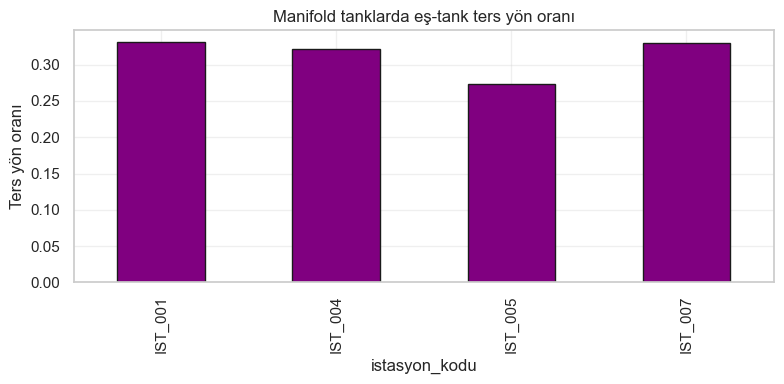

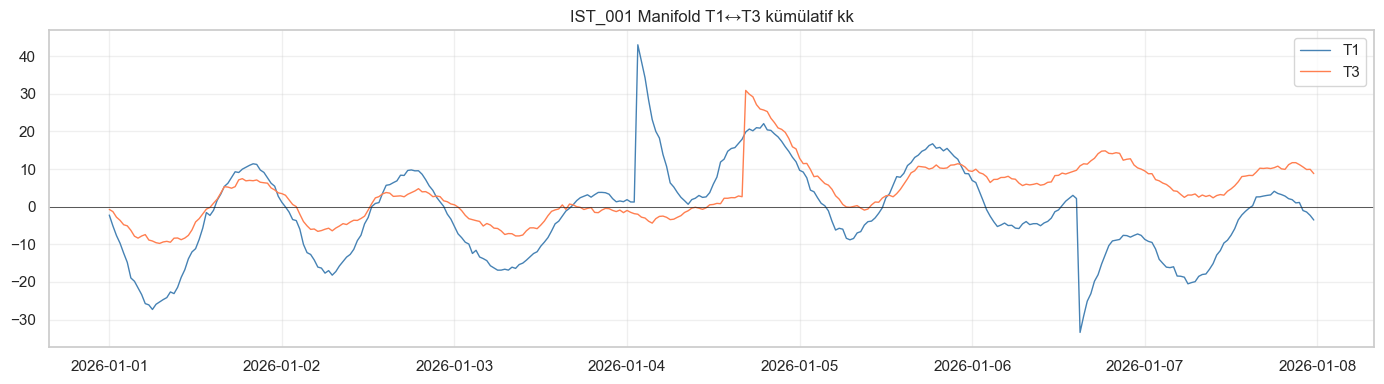

In [14]:
# Görselleştirme — manifold
plot_manifold_ters_yon(ue1t)
# örnek çift: IST_001 T1 vs T3
st, ta, tb = 'IST_001', 1, 3
fig, ax = plt.subplots(figsize=(14, 4))
for tk, c in [(ta, 'steelblue'), (tb, 'coral')]:
    g = ue1t[(ue1t.istasyon_kodu==st)&(ue1t.tank_no==tk)].sort_values('saat_1').iloc[:48*7]
    ax.plot(g['saat_1'], g['kayip_kazanc'].cumsum(), lw=1, label=f'T{tk}', color=c)
ax.axhline(0, color='k', lw=0.5)
ax.legend(); ax.set_title(f'{st} Manifold T{ta}↔T{tb} kümülatif kk')
plt.tight_layout(); show_fig()

## Feature seti — birleştirme ve kaydetme

Ground truth'u sadece **kontrol/etiket** amacıyla ekliyoruz (`anomali_etiketi`,
`anomali_kategorisi`). Bu iki kolon `y` — modele **X** olarak asla
verilmeyecek.

In [15]:
feature_cols = [
    'istasyon_kodu', 'tank_no', 'saat_1', 'saat_2',
    # zaman
    'saat', 'gece', 'vardiya', 'hafta_sonu',
    # satış-kayıp oranı
    'kk_oran', 'kk_oran_abs', 'satisiz_kayip',
    # sıcaklık
    'sicaklik', 'sicaklik_fark', 'sicaklik_gunluk_sapma', 'sicaklik_kayip_korelasyon',
    # hareketli ortalama
    'kayip_kazanc_ma_3', 'kayip_kazanc_ma_6', 'kayip_kazanc_ma_48', 'kk_oran_ma_6',
    # kümülatif eğim
    'kum_egim', 'kum_egim_r2',
    # manifold eş-tank
    'is_manifold', 'es_tank_kk_ort', 'es_tank_ters_yon',
    # ham referans kolonlar
    'kayip_kazanc', 'kumulatif_kayip_kazanc', 'pompa_satis', 'oran',
]

features = ue1t[feature_cols].merge(
    labels[['istasyon_kodu', 'tank_no', 'saat_1', 'anomali_etiketi', 'anomali_kategorisi']],
    on=['istasyon_kodu', 'tank_no', 'saat_1'], how='left',
)

out_path = DATA_ROOT / 'features.csv'
features.to_csv(out_path, index=False)
print('Kaydedildi:', out_path, features.shape)
features.head()

Kaydedildi: /Users/mangtay/Desktop/Staj/data/features.csv (138194, 30)


,istasyon_kodu,tank_no,saat_1,saat_2,saat,gece,vardiya,hafta_sonu,kk_oran,kk_oran_abs,satisiz_kayip,sicaklik,sicaklik_fark,sicaklik_gunluk_sapma,sicaklik_kayip_korelasyon,kayip_kazanc_ma_3,kayip_kazanc_ma_6,kayip_kazanc_ma_48,kk_oran_ma_6,kum_egim,kum_egim_r2,is_manifold,es_tank_kk_ort,es_tank_ters_yon,kayip_kazanc,kumulatif_kayip_kazanc,pompa_satis,oran,anomali_etiketi,anomali_kategorisi
0,IST_001,1,2026-01-01 00:00:00,2026-01-01 00:30:00,0,1,gece,0,-0.018065,0.018065,0,19.86,NaN,0.012708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,-0.72,0,-2.22,-2.22,122.89,-1.81,0,normal
1,IST_001,1,2026-01-01 00:30:00,2026-01-01 01:00:00,0,1,gece,0,-0.018686,0.018686,0,19.66,-0.20,-0.187292,NaN,-2.545000,-2.545000,NaN,-0.018376,NaN,NaN,1,-0.58,0,-2.87,-5.09,153.59,-1.87,0,normal
2,IST_001,1,2026-01-01 01:00:00,2026-01-01 01:30:00,1,1,gece,0,-0.173972,0.173972,0,19.53,-0.13,-0.317292,NaN,-2.556667,-2.556667,NaN,-0.070241,NaN,NaN,1,-1.48,0,-2.58,-7.67,14.83,-17.40,0,normal
3,IST_001,1,2026-01-01 01:30:00,2026-01-01 02:00:00,1,1,gece,0,NaN,NaN,0,19.39,-0.14,-0.457292,NaN,-2.500000,-2.430000,NaN,-0.070241,NaN,NaN,1,-0.85,0,-2.05,-9.72,0.00,0.00,0,normal
4,IST_001,1,2026-01-01 02:00:00,2026-01-01 02:30:00,2,1,gece,0,NaN,NaN,0,19.22,-0.17,-0.627292,NaN,-2.416667,-2.468000,NaN,-0.070241,NaN,NaN,1,-1.16,0,-2.62,-12.34,0.00,0.00,0,normal


Anomali oranı: 0.0237


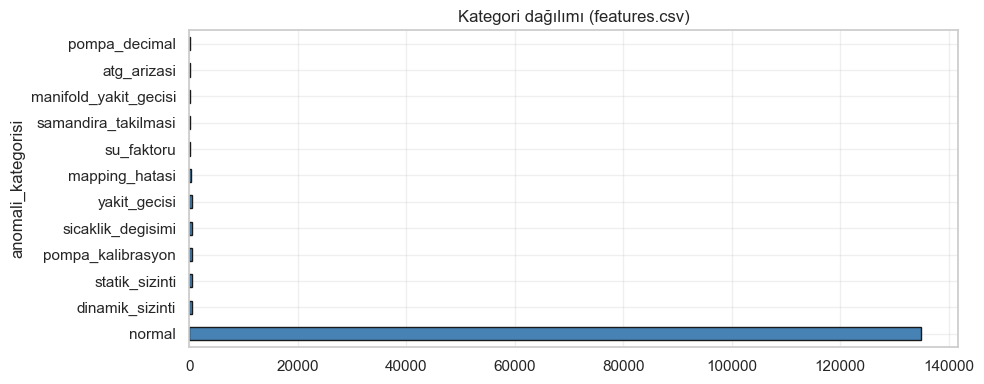

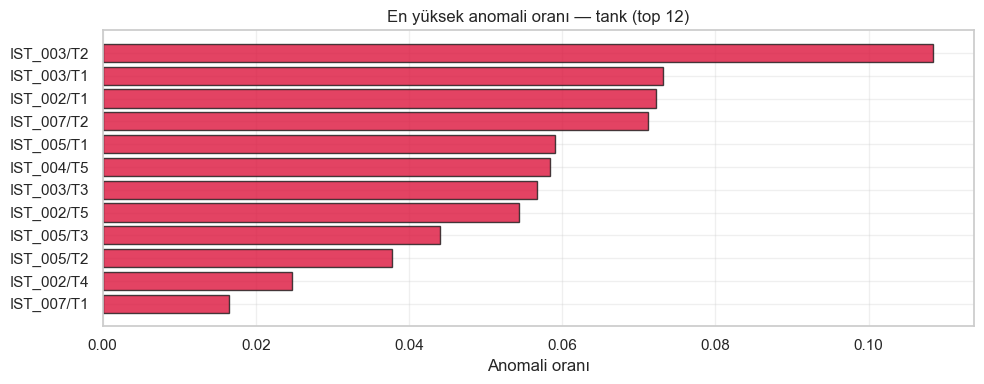

In [16]:
# Görselleştirme — etiket dağılımı
print('Anomali oranı:', features['anomali_etiketi'].mean().round(4))
fig, ax = plt.subplots(figsize=(10, 4))
features['anomali_kategorisi'].fillna('normal').value_counts().head(12).plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='k')
ax.set_title('Kategori dağılımı (features.csv)')
plt.tight_layout(); show_fig()
plot_anomaly_rate_by_tank(features)

## Hızlı sağlık kontrolü

Her feature grubunun ilgili alarm kategorisinde gerçekten ayrıştığını
görmek için kategori bazlı ortalamalara bakalım (leakage değil — sadece
feature'ın işe yaradığını doğrulamak için).

In [17]:
check_cols = [
    'kk_oran_abs', 'sicaklik_fark', 'sicaklik_kayip_korelasyon',
    'kayip_kazanc_ma_48', 'kum_egim', 'kum_egim_r2', 'es_tank_ters_yon',
]
ozet = (
    features[features['anomali_kategorisi'].notna()]
    .groupby('anomali_kategorisi')[check_cols]
    .mean()
    .round(3)
)
kategoriler = [
    'normal', 'statik_sizinti', 'dinamik_sizinti', 'sicaklik_degisimi',
    'pompa_kalibrasyon', 'manifold_yakit_gecisi', 'yakit_gecisi',
]
mevcut = [k for k in kategoriler if k in ozet.index]
ozet.loc[mevcut]

,kk_oran_abs,sicaklik_fark,sicaklik_kayip_korelasyon,kayip_kazanc_ma_48,kum_egim,kum_egim_r2,es_tank_ters_yon
anomali_kategorisi,,,,,,,
normal,0.028,-0.006,0.633,0.224,0.327,0.735,0.077
statik_sizinti,0.202,-0.003,0.525,-5.464,-5.899,0.964,0.277
dinamik_sizinti,0.044,0.020,0.354,-1.773,-1.823,0.789,0.000
sicaklik_degisimi,0.981,1.836,0.995,0.389,1.299,0.284,0.085
pompa_kalibrasyon,0.029,0.029,0.421,-0.996,-0.997,0.752,0.190
manifold_yakit_gecisi,7.057,-0.016,0.018,-0.425,-0.724,0.252,1.000
yakit_gecisi,0.174,0.039,0.300,1.568,1.010,0.455,0.000


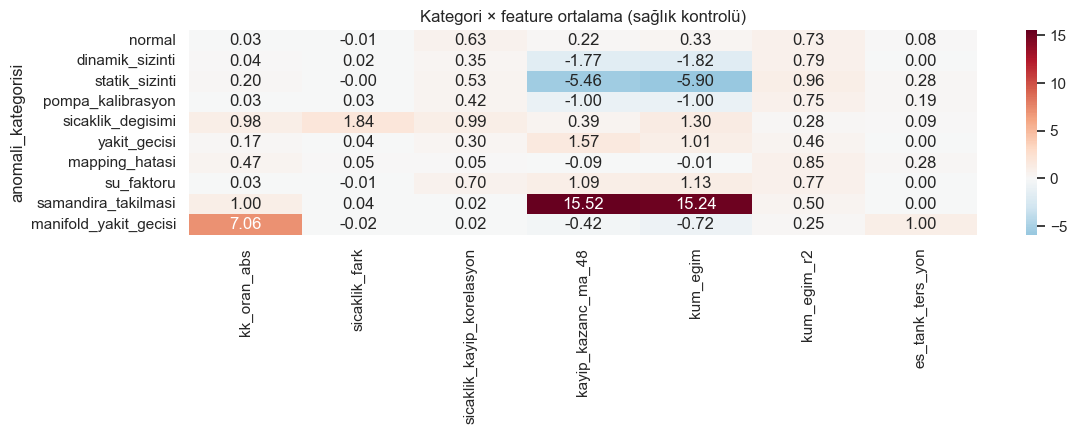

In [18]:
# Görselleştirme — kategori × feature heatmap
check_cols = [
    'kk_oran_abs', 'sicaklik_fark', 'sicaklik_kayip_korelasyon',
    'kayip_kazanc_ma_48', 'kum_egim', 'kum_egim_r2', 'es_tank_ters_yon',
]
plot_category_feature_means(features, check_cols)

**Yorum yeri (kodu çalıştırdıktan sonra doldur):**
- `kk_oran_abs`: pompa_kalibrasyon / dinamik_sizinti'de normal'e göre ne kadar yüksek?
- `sicaklik_kayip_korelasyon`: sicaklik_degisimi'de gerçekten yüksek mi (termal imza)?
- `kayip_kazanc_ma_48`: statik_sizinti'de sürekli mi negatif?
- `kum_egim_r2`: statik_sizinti'de yüksek (düzgün eğim), manipülasyon/mapping_hatasi'de düşük mü?
- `es_tank_ters_yon`: manifold_yakit_gecisi / yakit_gecisi'de belirgin şekilde daha yüksek mi?

Gün 9'da bu tabloyu SQL sorgularıyla üretmeyi deneyeceğiz.